# Per-class volume experiment — new GACC ($\gamma_T$) and ACC ($\alpha_T$)

This notebook loads the per-class mean-width results (V3k pipeline) and computes:

- **$\alpha_T$** — classical accuracy of the original FP model and each $b$-bit quantised model over the loaded samples  
- **$\gamma_T$** — new generalised accuracy (GACC), defined as
$$
\gamma_T = \frac{\displaystyle\sum_{x_i \in T} V_3^{(c_i)}(x_i)}{\displaystyle\sum_{x_i \in T} \sum_{k=0}^{9} V_3^{(k)}(x_i)}
$$
where $c_i$ is the correct class of sample $x_i$ (stored in the JSON result file)  
and $V_3^{(k)}(x_i) = \bar{w}(P_3^{(k)}(x_i))$ is the mean width of the polytope where the quantised model predicts class $k$.

**Containment:** $P_1(x) \supseteq P_2(x) \supseteq P_3^{(k)}(x)$

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import json, math, os, sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(ROOT))

from src.models.networks       import FashionMLP_Large
from src.quantization.quantize import quantize_model

DEVICE      = torch.device("cpu")
SAVE_PDF    = True
RESULTS_DIR = ROOT / "results" / "volumes_v3k_mlp"
DATA_FILE   = ROOT / "data" / "fashionMNIST_correct_mlp.pt"
CKPT_FILE   = ROOT / "checkpoints" / "fashion_mlp_best.pth"

print("Project root:", ROOT)
print("Results dir: ", RESULTS_DIR)
print("Data file:   ", DATA_FILE)

Project root: /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes
Results dir:  /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/volumes_v3k_mlp
Data file:    /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/data/fashionMNIST_correct_mlp.pt


## Load results

In [2]:
records = []
for f in sorted(RESULTS_DIR.glob("volumes_sample*.json"), key=lambda p: int(p.stem.split("sample")[1])):
    with open(f) as fh:
        records.append(json.load(fh))

bits_grid = records[0]["bits_grid"]   # e.g. [4, 6, 8, 10, 12, 16]

print(f"Loaded {len(records)} samples")
print(f"bits_grid = {bits_grid}")
print(f"Sample indices: {records[0]['sample_idx']} … {records[-1]['sample_idx']}")

# Quick sanity check
r0 = records[0]
print(f"\nExample (sample {r0['sample_idx']}):")
print(f"  class_c       = {r0['class_c']}")
print(f"  width_base    = {r0['width_base']:.4f}")
print(f"  widths_correct (b=4) = {r0['widths_correct']['4']:.4f}")
print(f"  widths_both   (b=4)  = {[round(v,2) for v in r0['widths_both']['4']]}")

Loaded 358 samples
bits_grid = [4, 6, 8, 10, 12, 16]
Sample indices: 0 … 359

Example (sample 0):
  class_c       = 9
  width_base    = 39.6722
  widths_correct (b=4) = 37.2921
  widths_both   (b=4)  = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 37.29]


## Compute new GACC $\gamma_T$

$$
\gamma_T(b) = \frac{\sum_i V_3^{(c_i)}(x_i)}{\sum_i \sum_{k=0}^{9} V_3^{(k)}(x_i)}
$$

The numerator uses index `class_c` from the JSON to pick $V_3^{(c_i)}$ from the 10-element list `widths_both[b]`.  
The denominator sums all 10 entries of `widths_both[b]` for every sample.

In [3]:
def compute_new_gacc(records, bits_grid):
    """
    Returns arrays (gamma, n_zero_num, n_zero_denom) of length len(bits_grid).

    gamma[i]        = sum_j V3_c(x_j) / sum_j sum_k V3_k(x_j)   for bits_grid[i]
    n_zero_num[i]   = #samples where V3_c = 0   (qmodel never predicts c inside P2)
    n_zero_denom[i] = #samples where ALL V3_k = 0
    """
    sum_num   = {b: 0.0 for b in bits_grid}
    sum_denom = {b: 0.0 for b in bits_grid}
    n_zero_num   = {b: 0 for b in bits_grid}
    n_zero_denom = {b: 0 for b in bits_grid}

    for r in records:
        c = r["class_c"]
        for b in bits_grid:
            widths_k = r["widths_both"][str(b)]   # list of 10 floats
            v3_c     = widths_k[c]
            v3_sum   = sum(widths_k)

            sum_num[b]   += v3_c
            sum_denom[b] += v3_sum

            if v3_c == 0.0 or math.isnan(v3_c):
                n_zero_num[b] += 1
            if v3_sum == 0.0 or math.isnan(v3_sum):
                n_zero_denom[b] += 1

    gamma = np.array([
        sum_num[b] / sum_denom[b] if sum_denom[b] > 0 else float("nan")
        for b in bits_grid
    ])
    return gamma, [n_zero_num[b] for b in bits_grid], [n_zero_denom[b] for b in bits_grid]


gamma_T, n_zero_num, n_zero_denom = compute_new_gacc(records, bits_grid)

print("New GACC γ_T per bit-width:")
print(f"  {'bits':>5}  {'γ_T':>10}  {'#V3_c=0':>10}  {'#all_k=0':>10}")
for i, b in enumerate(bits_grid):
    print(f"  {b:5d}  {gamma_T[i]:10.6f}  {n_zero_num[i]:10d}  {n_zero_denom[i]:10d}")

New GACC γ_T per bit-width:
   bits         γ_T     #V3_c=0    #all_k=0
      4    0.969213           1           0
      6    0.997355           0           0
      8    0.997392           0           0
     10    0.997533           0           0
     12    0.997514           0           0
     16    0.997536           0           0


## Compute old GACC $\gamma^{\mathrm{old}}_T$

$$
\gamma^{\mathrm{old}}_T(b) = \frac{\displaystyle\sum_{x_i \in T} V_3^{(c_i)}(x_i)}{\displaystyle\sum_{x_i \in T} V_2(x_i)}
$$

The numerator is the **same** as $\gamma_T$ (mean width of $P_3^{(c_i)}$, i.e. `widths_both[b][class_c]`).  
The denominator is $\sum_i V_2(x_i)$, i.e. `widths_correct[b]`.

Because of mean-width non-additivity ($\sum_k V_3^{(k)} \approx 2 \times V_2$ for q-incorrect samples),
the old GACC stays close to 1 even when the q-model is inaccurate, whereas the new GACC correctly drops to ~0.5.

In [4]:
def compute_old_gacc(records, bits_grid):
    """
    Old GACC = sum_i V3_c(x_i) / sum_i V2(x_i)

    Numerator:   widths_both[b][class_c]  — same as new GACC numerator
    Denominator: widths_correct[b]        — V2 = mean width of P2
    """
    sum_num   = {b: 0.0 for b in bits_grid}
    sum_denom = {b: 0.0 for b in bits_grid}

    for r in records:
        c = r["class_c"]
        for b in bits_grid:
            v3_c = r["widths_both"][str(b)][c]   # V3 at correct class
            v2   = r["widths_correct"][str(b)]    # V2
            sum_num[b]   += v3_c
            sum_denom[b] += v2

    return np.array([
        sum_num[b] / sum_denom[b] if sum_denom[b] > 0 else float("nan")
        for b in bits_grid
    ])


gamma_T_old = compute_old_gacc(records, bits_grid)

print("Old vs new GACC:")
print(f"  {'bits':>5}  {'γ^old_T':>12}  {'γ_T (new)':>12}  {'difference':>12}")
for i, b in enumerate(bits_grid):
    diff = gamma_T_old[i] - gamma_T[i]
    print(f"  {b:5d}  {gamma_T_old[i]:12.6f}  {gamma_T[i]:12.6f}  {diff:+12.6f}")

Old vs new GACC:
   bits       γ^old_T     γ_T (new)    difference
      4      0.997128      0.969213     +0.027916
      6      1.000000      0.997355     +0.002645
      8      1.000000      0.997392     +0.002608
     10      1.000000      0.997533     +0.002467
     12      1.000000      0.997514     +0.002486
     16      1.000000      0.997536     +0.002464


## Load models and compute ACC $\alpha_T$

$\alpha_T(b)$ = fraction of samples in $T$ correctly classified by the $b$-bit quantised model.

In [5]:
# ── Load full-precision model ─────────────────────────────────────────────────
fp_model = FashionMLP_Large()
fp_model.load_state_dict(torch.load(CKPT_FILE, map_location=DEVICE, weights_only=True))
fp_model.eval().to(DEVICE)
print("Loaded FP model.")

# ── Build quantised models ────────────────────────────────────────────────────
qmodels = {b: quantize_model(fp_model, bits=b).eval().to(DEVICE) for b in bits_grid}
print(f"Built {len(qmodels)} quantised models: bits = {list(qmodels.keys())}")

# ── Load dataset (local path override) ───────────────────────────────────────
dataset = torch.load(DATA_FILE, map_location=DEVICE, weights_only=False)
print(f"Loaded dataset: {len(dataset)} samples")

# ── Compute accuracies ────────────────────────────────────────────────────────
@torch.no_grad()
def predict(model, x):
    return int(model(x.unsqueeze(0).to(DEVICE)).argmax(dim=1).item())

n   = len(records)
cf  = 0
cq  = {b: 0 for b in bits_grid}

for r in records:
    x, c = dataset[r["sample_idx"]]
    c = int(c)
    # Sanity: class in dataset should match class_c in JSON
    assert c == r["class_c"], f"Class mismatch at sample {r['sample_idx']}: dataset={c}, json={r['class_c']}"
    if predict(fp_model, x) == c:
        cf += 1
    for b, qm in qmodels.items():
        if predict(qm, x) == c:
            cq[b] += 1

alpha_T_fp = cf / n
alpha_T    = {b: cq[b] / n for b in bits_grid}

print(f"\nACC α_T over {n} samples:")
print(f"  FP model : {alpha_T_fp:.6f}")
for b in bits_grid:
    print(f"  b={b:2d}      : {alpha_T[b]:.6f}")

Loaded FP model.
Built 6 quantised models: bits = [4, 6, 8, 10, 12, 16]
Loaded dataset: 56680 samples

ACC α_T over 358 samples:
  FP model : 1.000000
  b= 4      : 0.994413
  b= 6      : 1.000000
  b= 8      : 1.000000
  b=10      : 1.000000
  b=12      : 1.000000
  b=16      : 1.000000


## Summary table — $\alpha_T$ vs $\gamma_T$

In [6]:
print(f"MLP — {n} samples from fashionMNIST_correct_mlp.pt")
print()
print(f"  {'bits':>5}  {'α_T (ACC)':>12}  {'γ_T (new)':>12}  {'γ^old_T':>12}  {'#V3_c=0':>10}")
print(f"  {'FP':>5}  {alpha_T_fp:12.6f}  {'—':>12}  {'—':>12}  {'—':>10}")
for i, b in enumerate(bits_grid):
    print(f"  {b:5d}  {alpha_T[b]:12.6f}  {gamma_T[i]:12.6f}  {gamma_T_old[i]:12.6f}  {n_zero_num[i]:10d}")

MLP — 358 samples from fashionMNIST_correct_mlp.pt

   bits     α_T (ACC)     γ_T (new)       γ^old_T     #V3_c=0
     FP      1.000000             —             —           —
      4      0.994413      0.969213      0.997128           1
      6      1.000000      0.997355      1.000000           0
      8      1.000000      0.997392      1.000000           0
     10      1.000000      0.997533      1.000000           0
     12      1.000000      0.997514      1.000000           0
     16      1.000000      0.997536      1.000000           0


## Plot — $\alpha_T$ and $\gamma_T$ vs bit-width

Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/figures/plot_gacc_acc_v3k_mlp.pdf


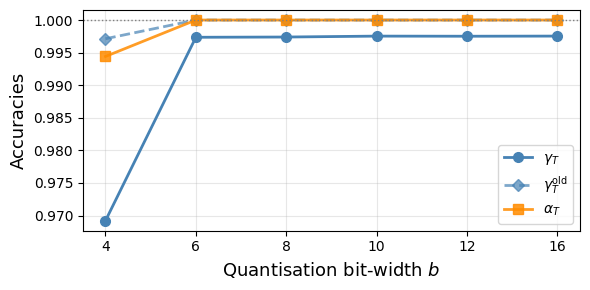

In [14]:
x        = np.arange(len(bits_grid))
acc_vals = np.array([alpha_T[b] for b in bits_grid])

fig, ax = plt.subplots(figsize=(6, 3))

ax.plot(x, gamma_T,     marker="o", linewidth=2, markersize=7, color="steelblue",
        label=r"$\gamma_T$")
ax.plot(x, gamma_T_old, marker="D", linewidth=2, markersize=6, color="steelblue",
        linestyle="--", alpha=0.7,
        label=r"$\gamma^{\mathrm{old}}_T$")
ax.plot(x, acc_vals,    marker="s", linewidth=2, markersize=7, color="darkorange", alpha=0.85,
        label=r"$\alpha_T$")
ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)

ax.set_xlabel("Quantisation bit-width $b$", fontsize=13)
ax.set_ylabel("Accuracies", fontsize=13)
# ax.set_title(f"MLP — GACC and ACC  [{n} samples]", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(bits_grid)
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
if SAVE_PDF:
    out = ROOT / "results" / "figures" / "plot_gacc_acc_v3k_mlp.pdf"
    out.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out, bbox_inches="tight")
    print(f"Saved to {out}")
plt.show()

## Mean widths — $V_1$, $V_2$, $\sum_k V_3^{(k)}$, $V_3^{(c)}$

Visual check of how the four width quantities evolve with bit-width.

                  mean         std
V1 (base)      39.8226      0.5691

   bits     mean V2   mean V3_c    mean ΣV3_k
      4     37.6739     37.5657       38.7590
      6     39.2656     39.2656       39.3698
      8     39.6784     39.6784       39.7822
     10     39.7872     39.7872       39.8856
     12     39.8150     39.8150       39.9142
     16     39.8220     39.8220       39.9204
Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/figures/plot_mean_widths_v3k_mlp.pdf


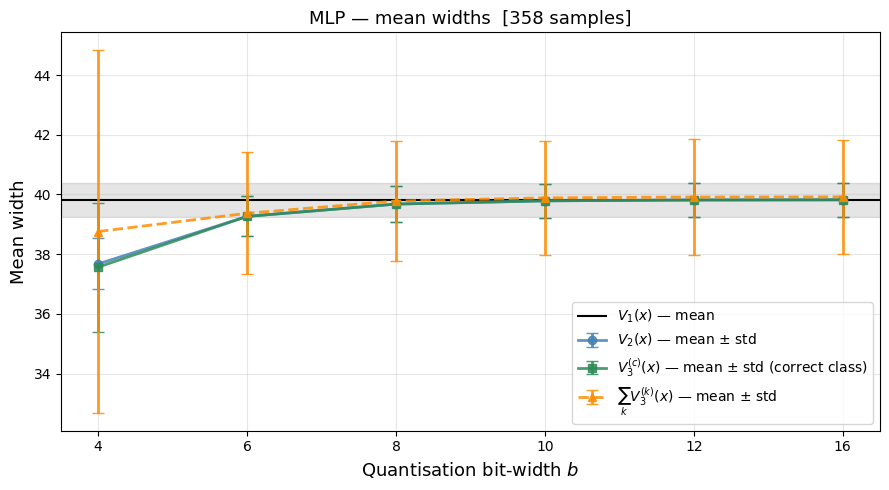

In [8]:
arr_base    = np.array([r["width_base"] for r in records])
arr_correct = {b: np.array([r["widths_correct"][str(b)] for r in records]) for b in bits_grid}
arr_v3c     = {b: np.array([r["widths_both"][str(b)][r["class_c"]] for r in records]) for b in bits_grid}
arr_v3sum   = {b: np.array([sum(r["widths_both"][str(b)]) for r in records]) for b in bits_grid}

mean_base    = arr_base.mean()
std_base     = arr_base.std()
mean_correct = np.array([arr_correct[b].mean() for b in bits_grid])
std_correct  = np.array([arr_correct[b].std()  for b in bits_grid])
mean_v3c     = np.array([arr_v3c[b].mean()     for b in bits_grid])
std_v3c      = np.array([arr_v3c[b].std()      for b in bits_grid])
mean_v3sum   = np.array([arr_v3sum[b].mean()   for b in bits_grid])
std_v3sum    = np.array([arr_v3sum[b].std()    for b in bits_grid])

print(f"{'':10s}  {'mean':>10}  {'std':>10}")
print(f"{'V1 (base)':10s}  {mean_base:10.4f}  {std_base:10.4f}")
print()
print(f"  {'bits':>5}  {'mean V2':>10}  {'mean V3_c':>10}  {'mean ΣV3_k':>12}")
for i, b in enumerate(bits_grid):
    print(f"  {b:5d}  {mean_correct[i]:10.4f}  {mean_v3c[i]:10.4f}  {mean_v3sum[i]:12.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
x   = np.arange(len(bits_grid))
fig, ax = plt.subplots(figsize=(9, 5))

ax.axhline(mean_base, color="black", linewidth=1.5, linestyle="-",
           label=r"$V_1(x)$ — mean")
ax.axhspan(mean_base - std_base, mean_base + std_base, alpha=0.10, color="black")

ax.errorbar(x, mean_correct, yerr=std_correct, marker="o", linewidth=2, markersize=6,
            capsize=4, color="steelblue", alpha=0.85,
            label=r"$V_2(x)$ — mean ± std")

ax.errorbar(x, mean_v3c,   yerr=std_v3c,   marker="s", linewidth=2, markersize=6,
            capsize=4, color="seagreen", alpha=0.85,
            label=r"$V_3^{(c)}(x)$ — mean ± std (correct class)")

ax.errorbar(x, mean_v3sum, yerr=std_v3sum, marker="^", linewidth=2, markersize=6,
            capsize=4, color="darkorange", alpha=0.85, linestyle="--",
            label=r"$\sum_k V_3^{(k)}(x)$ — mean ± std")

ax.set_xlabel("Quantisation bit-width $b$", fontsize=13)
ax.set_ylabel("Mean width", fontsize=13)
ax.set_title(f"MLP — mean widths  [{n} samples]", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(bits_grid)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
if SAVE_PDF:
    out = ROOT / "results" / "figures" / "plot_mean_widths_v3k_mlp.pdf"
    out.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out, bbox_inches="tight")
    print(f"Saved to {out}")
plt.show()